  Accept;Acceptance;Sex;BCPM;GPA;VR;PS;WS;BS;MCAT;Apps
0                      D;0;F;3.59;3.62;11;9;9;9;38;5  
1                    A;1;M;3.75;3.84;12;13;8;12;45;3  
2                     A;1;F;3.24;3.23;9;10;5;9;33;19  
3                    A;1;F;3.74;3.69;12;11;7;10;40;5  
4                    A;1;F;3.53;3.38;9;11;4;11;35;11  
Index(['Accept;Acceptance;Sex;BCPM;GPA;VR;PS;WS;BS;MCAT;Apps'], dtype='str')

Cluster sizes:
Cluster
0    31
1    15
2     9
Name: count, dtype: int64

Cluster 0: 11, 12, 10, 38, 39, 40, 34, 54, 35, 62

Cluster 1: 10, 32, 36, 77, 72, 19, 82, 41, 89, 34

Cluster 2: 13, 10, 14, 98, 12, 48, 17, 71, 34, 39


/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_18561/159743345.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_col = df.select_dtypes(include="object").columns[0]


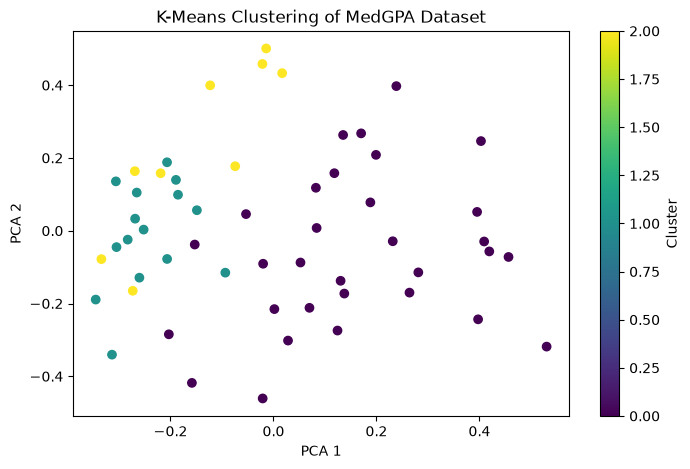


Results saved!


In [1]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 2. Load dataset
df = pd.read_csv("MedGPA.csv")
print(df.head())
print(df.columns)

# 3. Select text column
text_col = df.select_dtypes(include="object").columns[0]
text = df[text_col].fillna("").astype(str)

# 4. NLP: TF-IDF
tfidf = TfidfVectorizer(stop_words="english", max_features=2000)
X = tfidf.fit_transform(text)

# 5. K-Means clustering
k = 3
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["Cluster"] = model.fit_predict(X)

# 6. Show cluster sizes
print("\nCluster sizes:")
print(df["Cluster"].value_counts())

# 7. Show important words in each cluster
words = tfidf.get_feature_names_out()

for i in range(k):
    top_words = words[model.cluster_centers_[i].argsort()[-10:][::-1]]
    print(f"\nCluster {i}: {', '.join(top_words)}")

# 8. PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=df["Cluster"], cmap="viridis")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering of MedGPA Dataset")
plt.colorbar(label="Cluster")
plt.show()

# 9. Save results
df.to_csv("MedGPA_KMeans_Results.csv", index=False)
print("\nResults saved!")